# Mode Choice Prediction in Switzerland

## Reading the dataset

The data is presented as `txt` file, with tabulated columns.


In [164]:
import pandas as pd
import os

dataset = pd.read_csv("ModeChoiceOptima.txt", sep="\t")

# Create output figures directory
os.makedirs("figures", exist_ok=True)

dataset

,ID,DestAct,NbTransf,TimePT,WalkingTimePT,WaitingTimePT,CostPT,CostCar,TimeCar,NbHousehold,...,FreqTripHouseh,Region,distance_km,Choice,InVehicleTime,ModeToSchool,ReportedDuration,CoderegionCAR,age,Weight
0,10350017,2,4,85,23,10,12.4,3.17,32,2,...,4,1,30.0,1,52,3,255,1,27,0.000379
1,10350020,1,4,108,26,16,12.4,3.28,30,2,...,4,1,32.0,-1,66,3,150,1,28,0.000341
2,10350025,11,2,82,33,5,3.0,0.45,6,-1,...,2,1,4.5,0,44,-1,20,1,-1,0.000368
3,10350075,1,3,107,21,31,24.0,2.36,23,2,...,1,1,25.0,1,55,-1,30,1,63,0.000368
4,10350085,1,5,190,116,18,10.8,1.16,14,3,...,3,1,12.5,1,56,-1,20,1,57,0.000409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260,96040535,1,6,299,84,94,48.8,10.72,86,1,...,1,7,119.0,-1,121,6,90,7,51,0.000409
2261,96040537,8,0,139,116,0,14.4,3.18,43,5,...,3,7,32.0,1,23,5,70,7,46,0.000368
2262,96040537,8,0,71,57,0,6.0,0.94,12,5,...,3,7,9.0,1,14,5,20,7,46,0.000368
2263,96040538,11,2,118,70,10,11.4,1.77,24,5,...,4,7,17.5,1,38,3,30,7,49,0.000409


Five different datasets are to be analyzed, based on:

1. Structural features
2. Socio-economics features
3. Attitudinal features
4. All of the above


### Create Training & Validation Data


In [165]:
from enum import Enum
import numpy as np


class FeatureType(Enum):
    Numerical = 1
    Ordinal = 2
    Nominal = 3


structural_features = [
    ("NbTransf", FeatureType.Numerical),
    ("TimePT", FeatureType.Numerical),
    ("WalkingTimePT", FeatureType.Numerical),
    ("WaitingTimePT", FeatureType.Numerical),
    ("TimeCar", FeatureType.Numerical),
    ("CostPT", FeatureType.Numerical),
    ("MarginalCostPT", FeatureType.Numerical),
    ("CostCar", FeatureType.Numerical),
    ("TripPurpose", FeatureType.Nominal),
    ("TypeCommune", FeatureType.Nominal),
    ("ClassifCodeLine", FeatureType.Nominal),
    ("frequency", FeatureType.Ordinal),
    ("NbTrajects", FeatureType.Numerical),
    ("distance_km", FeatureType.Numerical),
    ("DestAct", FeatureType.Nominal),
    ("FreqTripHouseh", FeatureType.Ordinal),
]

socio_features = [
    ("age", FeatureType.Numerical),
    ("ModeToSchool", FeatureType.Nominal),
    ("ResidChild", FeatureType.Nominal),
    ("NbHousehold", FeatureType.Numerical),
    ("NbChild", FeatureType.Numerical),
    ("NbCar", FeatureType.Numerical),
    ("NbMoto", FeatureType.Numerical),
    ("NbBicy", FeatureType.Numerical),
    ("NbBicyChild", FeatureType.Numerical),
    ("NbComp", FeatureType.Numerical),
    ("NbTV", FeatureType.Numerical),
    ("Internet", FeatureType.Nominal),
    ("NewsPaperSubs", FeatureType.Nominal),
    ("NbCellPhones", FeatureType.Numerical),
    ("NbSmartPhone", FeatureType.Numerical),
    ("HouseType", FeatureType.Nominal),
    ("Income", FeatureType.Ordinal),
    ("Gender", FeatureType.Nominal),
    ("Mothertongue", FeatureType.Nominal),
    ("FamilSitu", FeatureType.Nominal),
    ("OccupStat", FeatureType.Nominal),
    ("SocioProfCat", FeatureType.Nominal),
    ("Education", FeatureType.Ordinal),
]

attitudinal_features = (
    [(f"Envir{str(i).zfill(2)}", FeatureType.Ordinal) for i in range(1, 7)]
    + [(f"Mobil{str(i).zfill(2)}", FeatureType.Ordinal) for i in range(1, 28)]
    + [(f"ResidCh{str(i).zfill(2)}", FeatureType.Ordinal) for i in range(1, 8)]
    + [(f"LifSty{str(i).zfill(2)}", FeatureType.Ordinal) for i in range(1, 15)]
)

global_features = structural_features + socio_features + attitudinal_features

features_groups = {
    "Structural": structural_features,
    "Socio": socio_features,
    "Attitudinal": attitudinal_features,
    "Global": global_features,
}


df = dataset[[f for f, _ in global_features] + ["Choice"]]
original_size = len(df)

missing_choice = df["Choice"] < 0
# Drop rows with missing target variable
df.drop(df[missing_choice].index, inplace=True)

missing_strategy = "impute"  # "drop" or "impute"

# Drop rows with missing features (negative values)
for feature, _ in global_features + [("Choice", FeatureType.Nominal)]:
    missing = df[feature] < 0
    if missing_strategy == "drop":
        df.drop(df[missing].index, inplace=True)
    elif missing_strategy == "impute":
        if missing.any():
            df.loc[missing, feature] = df[feature].median()

# Set all attitudinal features = 6 ("Don't know") to 3 ("Neutral")
# as removing them would lead to a significant loss of data
for feature, _ in attitudinal_features:
    invalid = df[feature] == 6
    df.loc[invalid, feature] = 3

rows_dropped = original_size - len(df)
print(f"Dropped {rows_dropped} rows.")
print(f"Dataset size after dropping: {len(df)} rows")

print(f"Features groups:")
for group, features in features_groups.items():
    print(f"- {group}: {len(features)} features")

Dropped 359 rows.
Dataset size after dropping: 1906 rows
Features groups:
- Structural: 16 features
- Socio: 23 features
- Attitudinal: 54 features
- Global: 93 features


In [166]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Choice"])
y = df["Choice"]

# Training: Fitting model weights
# Validation: Comparing models, tuning
# Test: Final evaluation of the best model on unseen data

validation_size = 0.2
test_size = 0.2

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=(test_size + validation_size),
    random_state=42,
    stratify=y,  # Make sure enough samples of each class are in both sets
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=test_size
    / (test_size + validation_size),  # Proportion of test size relative to the temp set
    random_state=42,
    stratify=y_temp,
)

print(f"Training set size: {len(X_train)} rows")
print(f"Validation set size: {len(X_val)} rows")
print(f"Test set size: {len(X_test)} rows")

Training set size: 1143 rows
Validation set size: 381 rows
Test set size: 382 rows


## Prepare Pipelines


In [167]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


get_preprocessor = lambda features: ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            [
                f
                for f, t in features
                if t == FeatureType.Numerical or t == FeatureType.Ordinal
            ],
        ),
        (
            "nom",
            OneHotEncoder(
                # Get all possible categories from the whole dataset to avoid issues with unseen categories in the validation/test sets
                categories=[
                    sorted(X[f].unique().tolist())
                    for f, t in features
                    if t == FeatureType.Nominal
                ],
                sparse_output=False,
            ),
            [f for f, t in features if t == FeatureType.Nominal],
        ),
    ]
)

get_pipeline = lambda features, classifier: Pipeline(
    steps=[
        ("preprocessor", get_preprocessor(features)),
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42)),
        ("classifier", classifier),
    ]
)

## Neural Network Layers Analysis


In [168]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss

# Analyze different choices of neural network
nn_layers = [
    (16),
    (24),
    (32),
    (48),
    (16, 8),
    (32, 8),
    (32, 16),
    (16, 32),
    (32, 16, 8),
]

nn_results = {}

print("Evaluating Neural Networks with different architectures...")
for layers in nn_layers:
    classifier = MLPClassifier(hidden_layer_sizes=layers, max_iter=10_000)
    pipeline = get_pipeline(global_features, classifier)
    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    ll = log_loss(y_test, y_pred_proba)

    print(f"- {str(layers):<15}: Accuracy = {acc:.4f}, Log Loss = {ll:.4f}")
    nn_results[str(layers)] = {"accuracy": acc, "log_loss": ll}

Evaluating Neural Networks with different architectures...
- 16             : Accuracy = 0.7853, Log Loss = 1.4793
- 24             : Accuracy = 0.7618, Log Loss = 1.2865
- 32             : Accuracy = 0.7827, Log Loss = 1.2301
- 48             : Accuracy = 0.7644, Log Loss = 1.2872
- (16, 8)        : Accuracy = 0.7749, Log Loss = 1.8568
- (32, 8)        : Accuracy = 0.7827, Log Loss = 1.4985
- (32, 16)       : Accuracy = 0.7801, Log Loss = 1.5704
- (16, 32)       : Accuracy = 0.7723, Log Loss = 1.7376
- (32, 16, 8)    : Accuracy = 0.7749, Log Loss = 1.5923


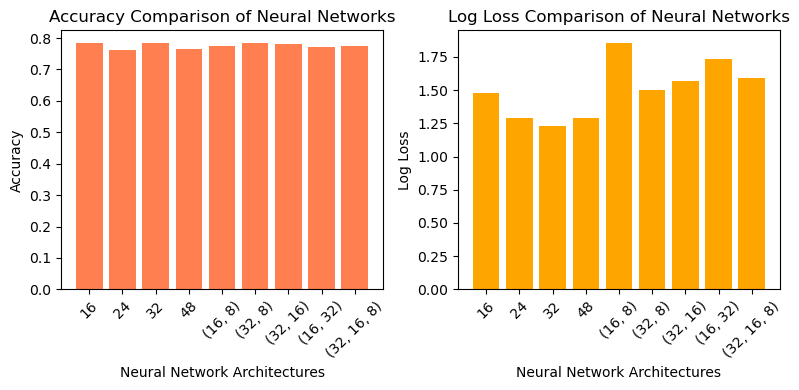

In [177]:
# Plot the NN results
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
# First plot: accuracy
plt.subplot(1, 2, 1)
plt.bar(
    list(nn_results.keys()),
    [res["accuracy"] for res in nn_results.values()],
    color="coral",
)
plt.xticks(rotation=45)
plt.xlabel("Neural Network Architectures")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Neural Networks")
plt.tight_layout()

# Second plot: log loss
plt.subplot(1, 2, 2)
plt.bar(
    list(nn_results.keys()),
    [res["log_loss"] for res in nn_results.values()],
    color="orange",
)
plt.xticks(rotation=45)
plt.xlabel("Neural Network Architectures")
plt.ylabel("Log Loss")
plt.title("Log Loss Comparison of Neural Networks")
plt.tight_layout()
plt.savefig("figures/nn_architectures_comparison.png")

## Define Classifiers


In [170]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=10_000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "XGBoost": XGBClassifier(random_state=42),
    "Neural Network": MLPClassifier(
        random_state=42, max_iter=10_000, hidden_layer_sizes=(32)
    ),
}

## Evaluate classifiers


In [171]:
results = {}

for group_name, features in features_groups.items():
    print(f"Evaluating classifiers on {group_name} features...")
    for clf_name, clf in classifiers.items():
        pipeline = get_pipeline(features, clf)
        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)
        y_pred_proba = pipeline.predict_proba(X_test)

        acc = accuracy_score(y_test, y_pred)
        ll = log_loss(y_test, y_pred_proba)

        print(f"- {clf_name:25s}: Accuracy = {acc:.4f}, Log Loss = {ll:.4f}")

        results[group_name] = results.get(group_name, {})
        results[group_name][clf_name] = {"accuracy": acc, "log_loss": ll}

Evaluating classifiers on Structural features...
- Logistic Regression      : Accuracy = 0.6780, Log Loss = 0.7761
- Decision Tree            : Accuracy = 0.7304, Log Loss = 6.0685
- XGBoost                  : Accuracy = 0.8194, Log Loss = 0.5289
- Neural Network           : Accuracy = 0.7435, Log Loss = 1.4617
Evaluating classifiers on Socio features...
- Logistic Regression      : Accuracy = 0.5602, Log Loss = 0.9434
- Decision Tree            : Accuracy = 0.6728, Log Loss = 4.7165
- XGBoost                  : Accuracy = 0.7330, Log Loss = 0.8703
- Neural Network           : Accuracy = 0.6780, Log Loss = 2.2814
Evaluating classifiers on Attitudinal features...
- Logistic Regression      : Accuracy = 0.6545, Log Loss = 0.8684
- Decision Tree            : Accuracy = 0.6754, Log Loss = 8.7518
- XGBoost                  : Accuracy = 0.7801, Log Loss = 0.8631
- Neural Network           : Accuracy = 0.7173, Log Loss = 2.2298
Evaluating classifiers on Global features...
- Logistic Regressio

## Results analysis


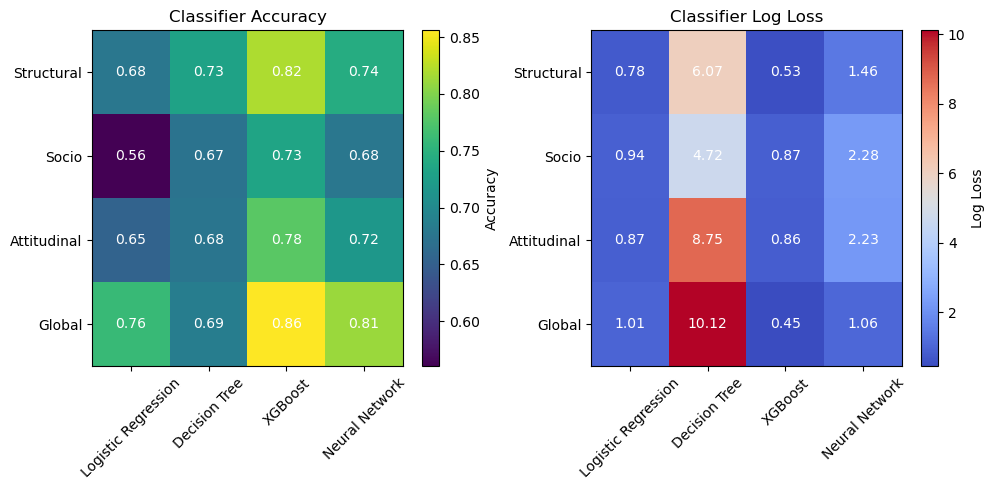

In [178]:
import matplotlib.pyplot as plt

# Create an heatmap of the accuracy scores for each classifier and feature group
accuracy_matrix = np.array(
    [
        [results[group][clf]["accuracy"] for clf in classifiers]
        for group in features_groups
    ]
)
log_loss_matrix = np.array(
    [
        [results[group][clf]["log_loss"] for clf in classifiers]
        for group in features_groups
    ]
)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(accuracy_matrix, cmap="viridis", aspect="auto")
plt.colorbar(label="Accuracy")
plt.xticks(ticks=range(len(classifiers)), labels=list(classifiers.keys()), rotation=45)
plt.yticks(ticks=range(len(features_groups)), labels=list(features_groups.keys()))
plt.title("Classifier Accuracy")

# add text annotations for each cell
for i in range(accuracy_matrix.shape[0]):
    for j in range(accuracy_matrix.shape[1]):
        plt.text(
            j,
            i,
            f"{accuracy_matrix[i, j]:.2f}",
            ha="center",
            va="center",
            color="white",
        )

plt.tight_layout()

plt.subplot(1, 2, 2)
plt.imshow(log_loss_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Log Loss")
plt.xticks(ticks=range(len(classifiers)), labels=list(classifiers.keys()), rotation=45)
plt.yticks(ticks=range(len(features_groups)), labels=list(features_groups.keys()))
plt.title("Classifier Log Loss")

# add text annotations for each cell
for i in range(log_loss_matrix.shape[0]):
    for j in range(log_loss_matrix.shape[1]):
        plt.text(
            j,
            i,
            f"{log_loss_matrix[i, j]:.2f}",
            ha="center",
            va="center",
            color="white",
        )

plt.tight_layout()
plt.savefig("figures/classifiers_comparison.png")

## SHAP Analysis of the Best Model


In [173]:
import shap


best_model = get_pipeline(features_groups["Global"], classifiers["XGBoost"])
best_model.fit(X_train, y_train)

preprocessor_scaler = Pipeline(
    best_model.steps[:-2]  # preprocessor + scaler, drop smote + classifier
)
X_shap = preprocessor_scaler.transform(X_test)
classifier = best_model.named_steps["classifier"]

explainer = shap.TreeExplainer(classifier)
X_shap = preprocessor_scaler.transform(X_test)
shap_values = explainer.shap_values(X_shap)

feature_names = preprocessor_scaler.get_feature_names_out()
# Remove prefix from feature names
feature_names = [name.split("__")[1] for name in feature_names]

get_explanation = lambda values: shap.Explanation(
    values=values,
    data=X_shap,
    feature_names=feature_names,
)

explanations = {
    "Public Transport": get_explanation(shap_values[:, :, 0]),
    "Car": get_explanation(shap_values[:, :, 1]),
    "Soft Modes": get_explanation(shap_values[:, :, 2]),
}

### Plot Features Importance for Each Mode


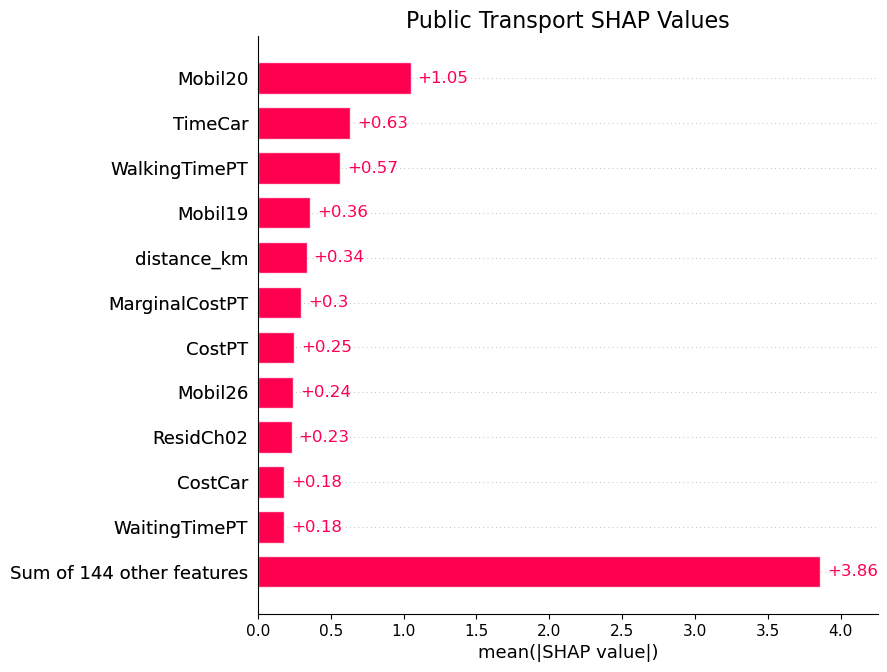

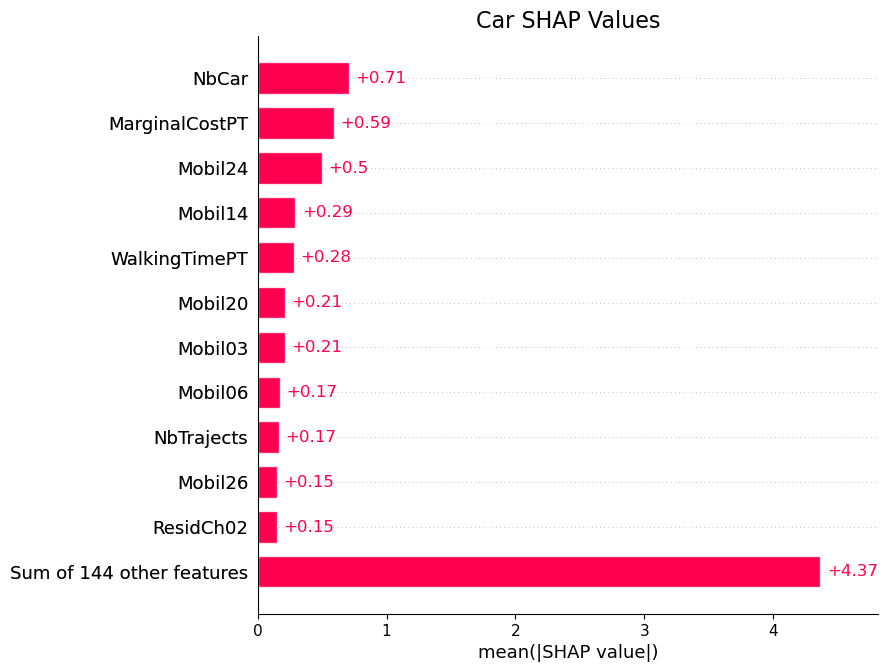

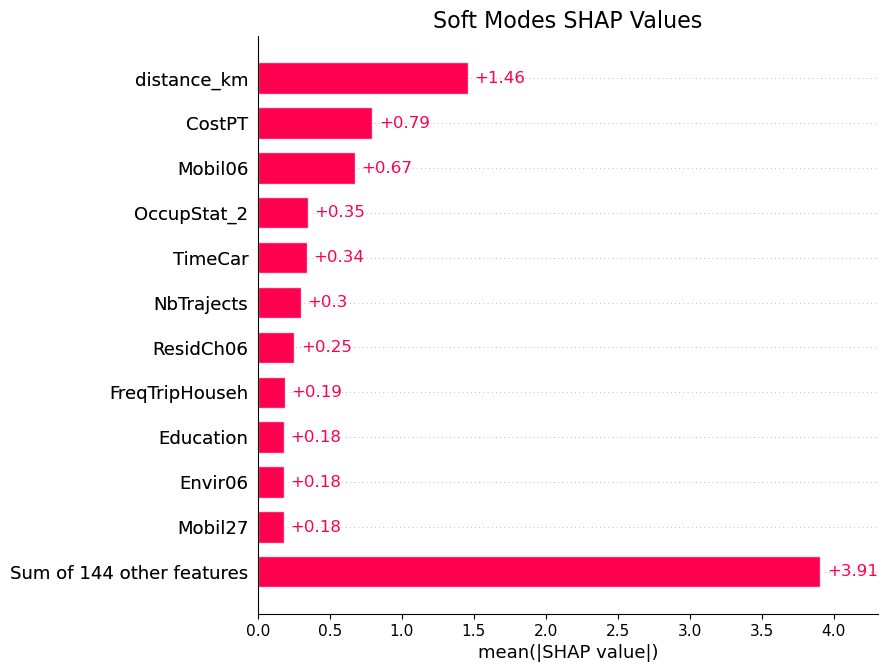

In [183]:
# Create a bar plot for each class
for idx, (class_name, explanation) in enumerate(explanations.items()):
    plt.figure(figsize=(6, 6))
    shap.plots.bar(
        explanation,
        max_display=12,
        show=False,
    )
    plt.title(f"{class_name} SHAP Values", fontsize=16)
    plt.savefig(
        f"figures/shap_bar_{class_name.lower().replace(' ', '_')}.png",
        bbox_inches="tight",  # Otherwise it's getting cut off
    )

### Plot Features Importance for Private Car Use


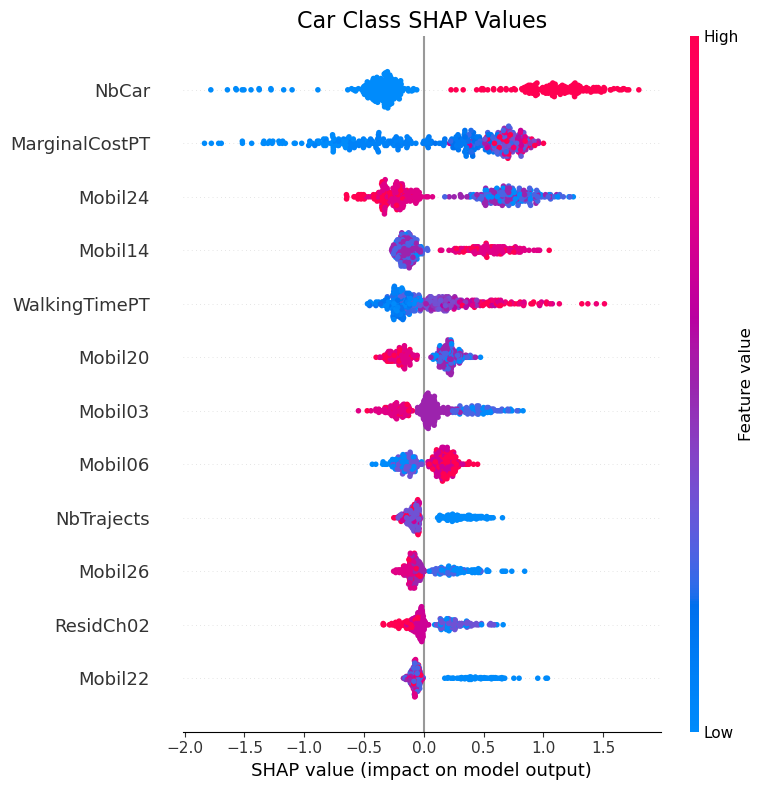

In [185]:
plt.figure(figsize=(8, 8))
plt.title("Car Class SHAP Values", fontsize=16)
shap.plots.beeswarm(
    explanations["Car"],
    plot_size=(8, 8),
    max_display=12,
    group_remaining_features=False,
    show=False,
)
plt.tight_layout()
plt.savefig("figures/shap_beeswarm_car.png", bbox_inches="tight")